In [1]:
import  pandas as pd 
import  numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df =pd.read_csv('911.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423909 entries, 0 to 423908
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        423909 non-null  float64
 1   lng        423909 non-null  float64
 2   desc       423909 non-null  object 
 3   zip        371780 non-null  float64
 4   title      423909 non-null  object 
 5   timeStamp  423909 non-null  object 
 6   twp        423750 non-null  object 
 7   addr       423909 non-null  object 
 8   e          423909 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 29.1+ MB


In [6]:
df.head(5)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [10]:
# to check top 5 zip values
df['zip'].value_counts().head(5)

zip
19401.0    28656
19464.0    27948
19403.0    21631
19446.0    20496
19406.0    14097
Name: count, dtype: int64

In [11]:
#to check same for township twp
df['twp'].value_counts().head(5)

twp
LOWER MERION    36441
ABINGTON        25835
NORRISTOWN      23883
UPPER MERION    22694
CHELTENHAM      19629
Name: count, dtype: int64

In [16]:
# to count and also check unique code in title 
df['title'].nunique()

141

In [18]:
# now we have to grab ems value from title column and create new column reason 
x =df['title'].iloc[0] # here we get fisrt string 

In [21]:
x.split(':')[0] # here we have grab the ems 

'EMS'

In [24]:
# now same above done in lambda functions 
df['reason']=df['title'].apply(lambda title: title.split(":")[0])

In [25]:
df['reason'] # here we get that output

0             EMS
1             EMS
2            Fire
3             EMS
4             EMS
           ...   
423904    Traffic
423905    Traffic
423906    Traffic
423907    Traffic
423908    Traffic
Name: reason, Length: 423909, dtype: object

In [27]:
# now from this column reason we have to most reasons 
df['reason'].value_counts() # so ems is most 

reason
EMS        208676
Traffic    151458
Fire        63775
Name: count, dtype: int64

C:\Users\vamtech\AppData\Local\Temp\ipykernel_4736\3608144010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reason',data=df,palette='viridis')


<Axes: xlabel='reason', ylabel='count'>

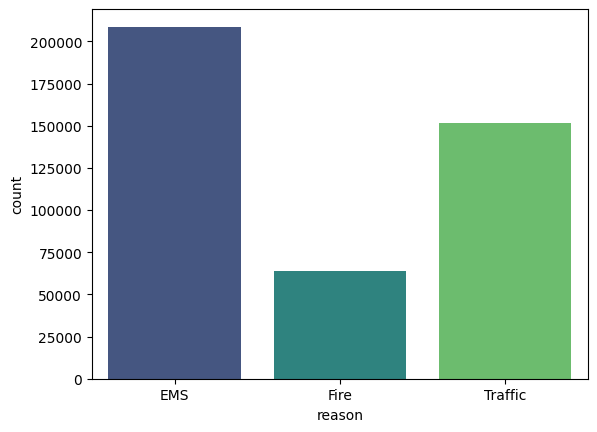

In [29]:
#using seaborn need to create countplot for 911 column reason 
sns.countplot(x='reason',data=df,palette='viridis')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423909 entries, 0 to 423908
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        423909 non-null  float64
 1   lng        423909 non-null  float64
 2   desc       423909 non-null  object 
 3   zip        371780 non-null  float64
 4   title      423909 non-null  object 
 5   timeStamp  423909 non-null  object 
 6   twp        423750 non-null  object 
 7   addr       423909 non-null  object 
 8   e          423909 non-null  int64  
 9   reason     423909 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 32.3+ MB


In [32]:
type(df['timeStamp'].iloc[0]) #to check column type 

str

In [34]:
df['timeStamp']=pd.to_datetime(df['timeStamp']) # here we have changed the column datatype to date_time
type(df['timeStamp'].iloc[0])

pandas._libs.tslibs.timestamps.Timestamp

In [38]:
time=df['timeStamp'].iloc[0]
time.hour # to check timeStamp is working for not we have checked for hrs

17

In [40]:
# create three new columnns hours,month,day of week

df['Hours']= df['timeStamp'].apply(lambda time:time.hour) #we have created here hours column we will do same for month,day of week
df['Hours']

0         17
1         17
2         14
3         16
4         16
          ..
423904     8
423905     8
423906     8
423907     8
423908     8
Name: Hours, Length: 423909, dtype: int64

In [41]:
df['Day of week']= df['timeStamp'].apply(lambda time:time.dayofweek) #we have created here Day of week column
df['Day of week']

0         3
1         3
2         3
3         3
4         3
         ..
423904    4
423905    4
423906    4
423907    4
423908    4
Name: Day of week, Length: 423909, dtype: int64

In [43]:
df['month']= df['timeStamp'].apply(lambda time:time.month) #we have created here Day of week column
df['month']

0         12
1         12
2         12
3         12
4         12
          ..
423904    11
423905    11
423906    11
423907    11
423908    11
Name: month, Length: 423909, dtype: int64

In [44]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,Hours,Day of week,month
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,3,12
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,3,12
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1,Fire,14,3,12
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,16,3,12
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,16,3,12


In [45]:
dmap = {0:'MON',1:'TUE',2:'WENS',3:'THUS',4:'FRI',5:'SAT',6:'SUN'}# we set int to str in the column day of week

In [46]:
df['Day of week'] =df['Day of week'].map(dmap)# we set int to str in the column day of week

In [47]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,Hours,Day of week,month
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,THUS,12
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,THUS,12
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1,Fire,14,THUS,12
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,16,THUS,12
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,16,THUS,12


<Axes: xlabel='Day of week', ylabel='count'>

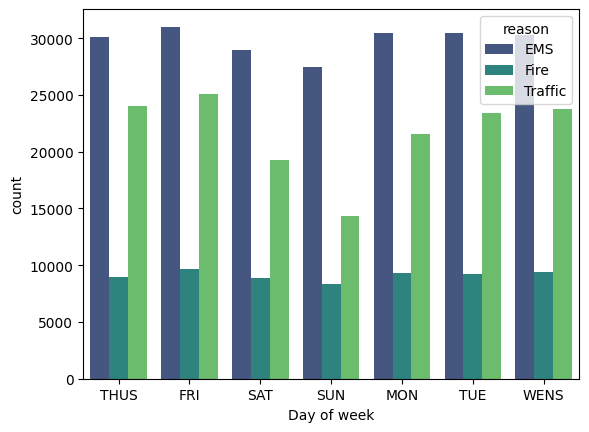

In [54]:
sns.countplot(x='Day of week',data=df,hue='reason',palette='viridis') #we have ploted coutplot for day of week with hue column

<Axes: xlabel='month', ylabel='count'>

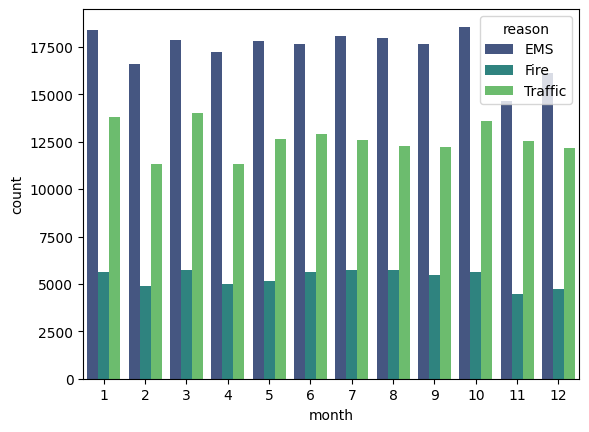

In [55]:
sns.countplot(x='month',data=df,hue='reason',palette='viridis') #same we have done for month

In [58]:
bymonth = df.groupby('month').count() #we are taking groupby of month
bymonth.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,Hours,Day of week
month,,,,,,,,,,,,
1,37824,37824,37824,33480,37824,37824,37812,37824,37824,37824,37824,37824
2,32828,32828,32828,28963,32828,32828,32817,32828,32828,32828,32828,32828
3,37666,37666,37666,33416,37666,37666,37651,37666,37666,37666,37666,37666
4,33583,33583,33583,29488,33583,33583,33575,33583,33583,33583,33583,33583
5,35644,35644,35644,31114,35644,35644,35628,35644,35644,35644,35644,35644


<Axes: xlabel='month'>

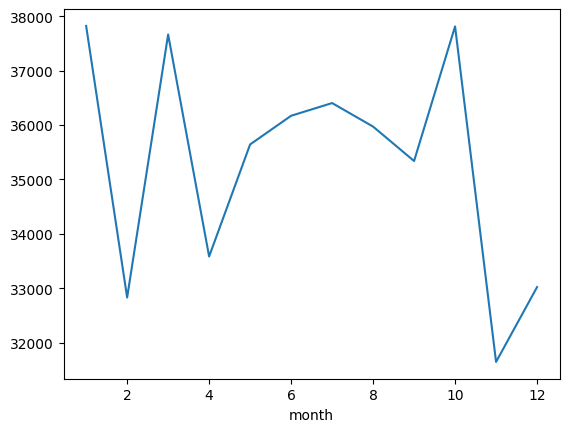

In [59]:
bymonth['lat'].plot()

bymonth.reset_index()

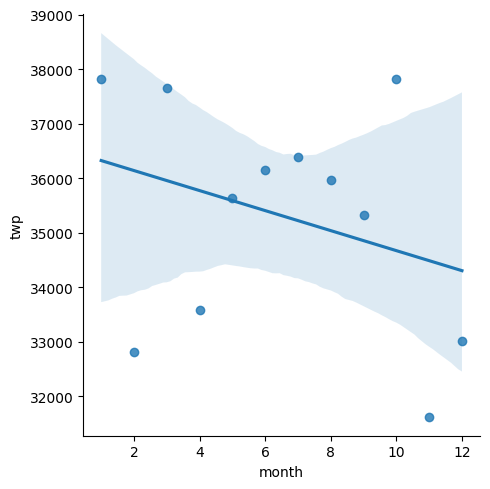

In [65]:
sns.lmplot(x='month', y='twp', data=bymonth.reset_index())  # for linear model


In [66]:
t= df['timeStamp'].iloc[0]

In [67]:
t

Timestamp('2015-12-10 17:10:52')

In [69]:
t.date()

datetime.date(2015, 12, 10)

In [70]:
t= df['timeStamp'].iloc[0]

In [73]:
df['Date']= df['timeStamp'].apply(lambda t:t.date())# Created a date column in df
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,Hours,Day of week,month,Date
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,THUS,12,2015-12-10
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,THUS,12,2015-12-10
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1,Fire,14,THUS,12,2015-12-10
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,16,THUS,12,2015-12-10
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,16,THUS,12,2015-12-10


In [74]:
df.groupby('Date').count().head() # just grouped by with date column 

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,reason,Hours,Day of week,month
Date,,,,,,,,,,,,,
2015-12-10,114,114,114,100,114,114,114,114,114,114,114,114,114
2015-12-11,391,391,391,332,391,391,391,391,391,391,391,391,391
2015-12-12,402,402,402,334,402,402,402,402,402,402,402,402,402
2015-12-13,316,316,316,279,316,316,316,316,316,316,316,316,316
2015-12-14,444,444,444,386,444,444,443,444,444,444,444,444,444


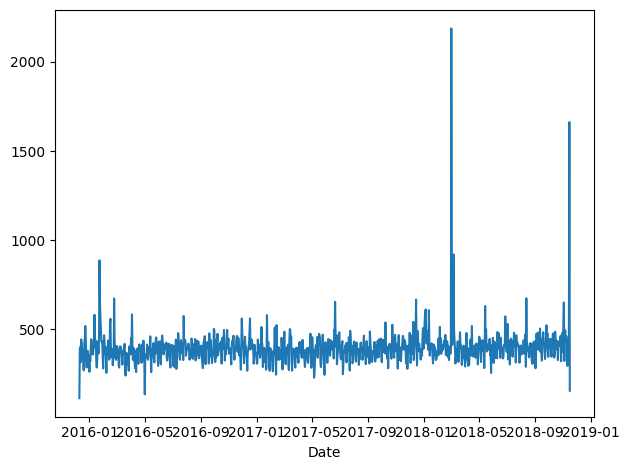

In [77]:
df.groupby('Date').count()['lat'].plot() #for lat
plt.tight_layout() # to reduce noise and see clear vision

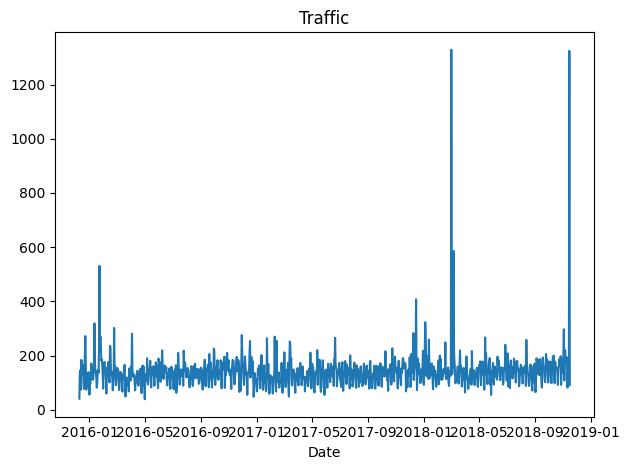

In [80]:
df[df['reason']== 'Traffic'].groupby('Date').count()['lat'].plot() # same as above but for traffic using column reason
plt.title('Traffic')
plt.tight_layout() # to reduce noise and see clear vision

In [88]:
dayhours= df.groupby(by=['Day of week','Hours']).count()['reason'].unstack()

<Axes: xlabel='Hours', ylabel='Day of week'>

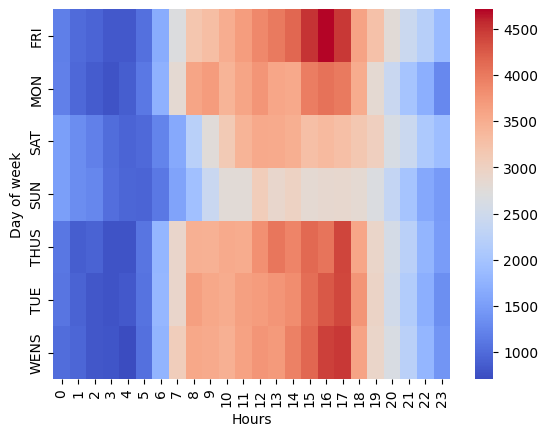

In [90]:
sns.heatmap(dayhours,cmap='coolwarm')